# A first EM algorithm

We ask one question. How can observed data estimate a model when a variable needed for simple estimation is hidden?

An expectation-maximization (EM) problem has three parts.

1. **Observed data.** $X$ is measured.
2. **Latent variable.** $Z$ is unobserved.
3. **Model.** $p(X,Z\mid\theta)$ connects the observed and latent variables through parameters $\theta$.

At iteration $t$, EM alternates two steps.

1. **E step.** Compute $p(Z\mid X,\theta^{(t)})$.
2. **M step.** Update $\theta$ using the expected complete data.

We use two Gaussian groups. Let $P(Z_i=1)=\pi$ and

$$X_i\mid Z_i=k\sim N(\mu_k,1),\qquad k\in\{0,1\}.$$

The unknown parameters are $\theta=(\pi,\mu_0,\mu_1)$.

The key property is likelihood ascent. Every E--M cycle raises or preserves the observed-data likelihood, starting from any valid parameter value.


## One fixed sample

We simulate one observed value from one of two hidden groups. The hidden label is shown because this is a teaching example. In real data, it is unknown. The observed value could, for example, be an apple weight and the hidden label its variety.


In [1]:
set.seed(8149)

n_sample <- 80L
hidden_group <- sample(rep(c(0, 1), each = n_sample / 2))
true_mean <- c(-1.5, 1.5)
observed <- rnorm(
  n_sample, mean = true_mean[hidden_group + 1], sd = 1
)

data.frame(
  observed = round(observed[1:8], 2),
  hidden_group = hidden_group[1:8]
)

observed,hidden_group
<dbl>,<dbl>
-2.18,0
2.33,1
0.41,1
2.79,1
3.11,1
-1.85,0
1.86,1
-0.69,0


## E step: infer the hidden group

Given the current parameters, calculate the probability that observation $i$ came from group 1.

$$
r_i^{(t)}
=P(Z_i=1\mid X_i=x_i,\theta^{(t)})
=\frac{\pi^{(t)}\phi(x_i;\mu_1^{(t)},1)}
{(1-\pi^{(t)})\phi(x_i;\mu_0^{(t)},1)
+\pi^{(t)}\phi(x_i;\mu_1^{(t)},1)}.
$$

$r_i^{(t)}$ is also $E[Z_i\mid X_i,\theta^{(t)}]$. It is the expected group-1 count contributed by observation $i$.


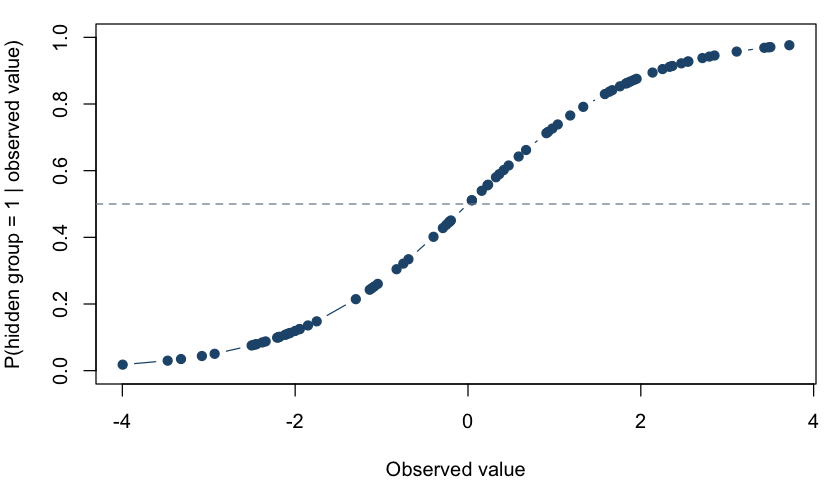

In [2]:
responsibility <- function(observed, pi, mu) {
  density_0 <- (1 - pi) * dnorm(observed, mean = mu[1], sd = 1)
  density_1 <- pi * dnorm(observed, mean = mu[2], sd = 1)
  density_1 / (density_0 + density_1)
}

start <- list(pi = 0.5, mu = c(-0.5, 0.5))
r <- responsibility(observed, start$pi, start$mu)
ordered <- order(observed)

options(repr.plot.width = 7, repr.plot.height = 4)
par(mar = c(4, 4, 1, 1))
plot(
  observed[ordered], r[ordered], type = "b", pch = 19,
  xlab = "Observed value",
  ylab = "P(hidden group = 1 | observed value)",
  ylim = c(0, 1), col = "#24567a"
)
abline(h = 0.5, lty = 2, col = "#7a8793")

A responsibility is not a hard group label. It measures uncertainty about the hidden group. Values near $1/2$ mean that the two groups remain difficult to distinguish.


## M step: update the parameters

Use the responsibilities as fractional group labels.

$$
\pi^{(t+1)}=\frac{1}{n}\sum_i r_i^{(t)},
$$

$$
\mu_0^{(t+1)}=\frac{\sum_i(1-r_i^{(t)})x_i}{\sum_i(1-r_i^{(t)})},\qquad
\mu_1^{(t+1)}=\frac{\sum_i r_i^{(t)}x_i}{\sum_i r_i^{(t)}}.
$$

In general, the M step maximizes the expected complete-data log likelihood.

$$
\theta^{(t+1)}=\arg\max_{\theta}
E_{Z\mid X,\theta^{(t)}}\left[\ell_c(\theta;X,Z)\right].
$$


In [3]:
observed_loglik <- function(observed, pi, mu) {
  density <-
    (1 - pi) * dnorm(observed, mean = mu[1], sd = 1) +
    pi * dnorm(observed, mean = mu[2], sd = 1)
  sum(log(density))
}

em_update <- function(observed, pi, mu) {
  r <- responsibility(observed, pi, mu)
  list(
    pi = mean(r),
    mu = c(
      sum((1 - r) * observed) / sum(1 - r),
      sum(r * observed) / sum(r)
    )
  )
}

fit_em <- function(observed, start, tolerance = 1e-8) {
  parameter <- start
  history <- data.frame(
    iteration = 0L, pi = parameter$pi,
    mu_0 = parameter$mu[1], mu_1 = parameter$mu[2],
    loglik = observed_loglik(observed, parameter$pi, parameter$mu)
  )

  for (iteration in seq_len(500L)) {
    updated <- em_update(observed, parameter$pi, parameter$mu)
    change <- max(abs(
      c(updated$pi, updated$mu) - c(parameter$pi, parameter$mu)
    ))
    parameter <- updated
    history <- rbind(
      history,
      data.frame(
        iteration = iteration, pi = parameter$pi,
        mu_0 = parameter$mu[1], mu_1 = parameter$mu[2],
        loglik = observed_loglik(
          observed, parameter$pi, parameter$mu
        )
      )
    )
    if (change < tolerance) break
  }

  parameter$history <- history
  parameter
}

fit <- fit_em(observed, start)

## Why the iteration works

The observed-data log likelihood contains a sum over the hidden variable.

$$
\ell(\theta;X)=\log\sum_Z p(X,Z\mid\theta).
$$

The E step uses the current parameters to construct a lower bound on this likelihood. The bound touches the likelihood at $\theta^{(t)}$. The M step raises the bound, so the observed-data likelihood cannot decrease.

$$
\ell(\theta^{(t+1)};X)\geq\ell(\theta^{(t)};X).
$$

Any valid initial value can start the iteration. Under the usual regularity conditions, the likelihood converges and the parameter estimates approach a stationary point. Different initial values can reach different stationary points, so a useful starting value can still matter.

## When EM applies

EM can be used when three operations are available.

1. Write a joint model $p(X,Z\mid\theta)$ in which estimation would be simpler if $Z$ were observed.
2. Compute $p(Z\mid X,\theta^{(t)})$, or the expectations needed from it.
3. Maximize the expected complete-data log likelihood to update $\theta$.

If these steps can be carried out, EM turns the incomplete-data problem into repeated complete-data calculations.


parameter,true_value,estimate
<chr>,<dbl>,<dbl>
pi,0.5,0.523
mu_0,-1.5,-1.726
mu_1,1.5,1.633


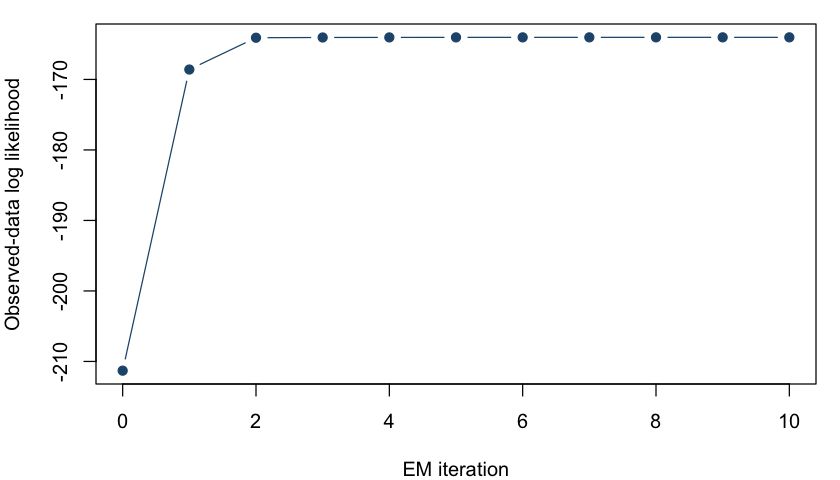

In [4]:
data.frame(
  parameter = c("pi", "mu_0", "mu_1"),
  true_value = c(0.5, true_mean),
  estimate = round(c(fit$pi, fit$mu), 3)
)

stopifnot(all(diff(fit$history$loglik) >= -1e-10))

shown <- fit$history[fit$history$iteration <= 10, ]
options(repr.plot.width = 7, repr.plot.height = 4)
par(mar = c(4, 4, 1, 1))
plot(
  shown$iteration, shown$loglik,
  type = "b", pch = 19, col = "#24567a",
  xlab = "EM iteration", ylab = "Observed-data log likelihood"
)

## What to remember

1. The **E step** computes a conditional distribution for the latent variable.
2. The **M step** fits the model using expected complete data.
3. Each iteration raises or preserves the observed-data likelihood. EM applies when both steps can be computed.

The [genotyping-error model](P8149_Lecture_2_MAF_MLE_EM.ipynb) uses the same structure. The latent variable is the true genotype, and the observed data are uncertain genotype measurements.
